# Seleksi Fitur — Random Forest Feature Importance
**Target:** `HadAngina` (CVDCRHD4) = Angina / Coronary Heart Disease  
**Dibuang dari fitur:** `HadAngina` (target), `HadHeartAttack` (data leakage), `State` (tidak relevan geografis)  
**Jumlah fitur k:** dipilih **otomatis** oleh algoritma via 5-Fold CV pada seluruh rentang k yang valid secara arsitektur CNN-LSTM

## 1. Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('heart_no_nans.csv')
print(f'Shape dataset : {df.shape}')
print(f'Kolom tersedia: {df.columns.tolist()}')

Shape dataset : (246022, 40)
Kolom tersedia: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


## 2. Tentukan Target & Kolom yang Dibuang

In [5]:
# ✅ TARGET YANG BENAR:
# HadAngina = CVDCRHD4 = '(Ever told) you had angina or coronary heart disease'
TARGET    = 'HadAngina'

# Kolom yang DIBUANG secara eksplisit beserta alasannya:
# - HadAngina      : ini adalah TARGET, tidak boleh jadi fitur
# - HadHeartAttack : komplikasi/akibat CHD → data leakage jika dipakai sebagai fitur
# - State          : kode negara bagian AS, tidak relevan untuk konteks Indonesia
DROP_COLS = [TARGET, 'HadHeartAttack', 'State']

print(f'Target        : {TARGET}')
print(f'Kolom dibuang : {DROP_COLS}')
print(f'\nDistribusi target:')
print(df[TARGET].value_counts())
print(f'Prevalensi CHD: {(df[TARGET]=="Yes").mean()*100:.2f}%')

Target        : HadAngina
Kolom dibuang : ['HadAngina', 'HadHeartAttack', 'State']

Distribusi target:
HadAngina
No     231069
Yes     14953
Name: count, dtype: int64
Prevalensi CHD: 6.08%


## 3. Encoding — Konsisten & Tersimpan untuk Backend
Encoding dilakukan **satu kali** menggunakan `LabelEncoder` per kolom.  
Target di-encode secara **terpisah dan eksplisit** (`Yes=1, No=0`) agar tidak bergantung urutan alfabetis.

In [7]:
df_work = df.copy()

# Encode TARGET secara eksplisit (Yes=1, No=0)
# Dilakukan TERPISAH agar dijamin Yes=1 dan No=0, tidak bergantung urutan alfabet LabelEncoder
df_work[TARGET] = df_work[TARGET].map({'Yes': 1, 'No': 0})
y = df_work[TARGET]

# Encode semua kolom FITUR kategorikal dengan LabelEncoder
# Encoder disimpan per kolom agar backend bisa encode input user dengan cara yang sama
encoders = {}
X_raw    = df_work.drop(columns=DROP_COLS)   # fitur saja, target & leakage sudah dibuang

for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        le            = LabelEncoder()
        X_raw[col]    = le.fit_transform(X_raw[col].astype(str))
        encoders[col] = le                   # simpan encoder kolom ini

X_full = X_raw.copy()

print(f'Jumlah fitur (setelah drop)  : {X_full.shape[1]}')
print(f'Distribusi y (0=Non-CHD, 1=CHD):')
print(y.value_counts())
print(f'Prevalensi CHD               : {y.mean()*100:.2f}%')

# Cek tidak ada NaN
assert X_full.isnull().sum().sum() == 0, 'Terdapat NaN di X_full!'
print('\n✅ Tidak ada NaN di fitur')

# Simpan encoder untuk backend
joblib.dump(encoders, 'encoders_rf.pkl')
print('✅ encoders_rf.pkl tersimpan')

Jumlah fitur (setelah drop)  : 37
Distribusi y (0=Non-CHD, 1=CHD):
HadAngina
0    231069
1     14953
Name: count, dtype: int64
Prevalensi CHD               : 6.08%

✅ Tidak ada NaN di fitur
✅ encoders_rf.pkl tersimpan


## 4. RF Feature Importance — Ranking Semua Fitur

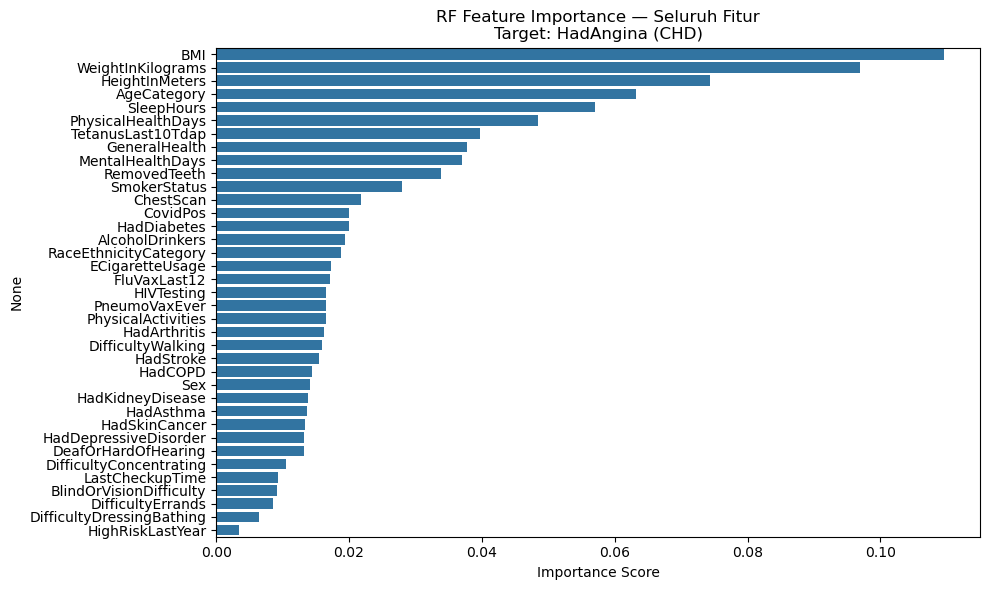

Ranking seluruh fitur:
BMI                          0.109508
WeightInKilograms            0.096853
HeightInMeters               0.074267
AgeCategory                  0.063181
SleepHours                   0.057070
PhysicalHealthDays           0.048477
TetanusLast10Tdap            0.039776
GeneralHealth                0.037779
MentalHealthDays             0.036963
RemovedTeeth                 0.033895
SmokerStatus                 0.027927
ChestScan                    0.021830
CovidPos                     0.020048
HadDiabetes                  0.019916
AlcoholDrinkers              0.019352
RaceEthnicityCategory        0.018748
ECigaretteUsage              0.017244
FluVaxLast12                 0.017067
HIVTesting                   0.016546
PneumoVaxEver                0.016541
PhysicalActivities           0.016448
HadArthritis                 0.016246
DifficultyWalking            0.015901
HadStroke                    0.015493
HadCOPD                      0.014473
Sex                        

In [9]:
rf_ranker = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ranker.fit(X_full, y)

importances        = pd.Series(rf_ranker.feature_importances_, index=X_full.columns)
importances_sorted = importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index)
plt.title('RF Feature Importance — Seluruh Fitur\nTarget: HadAngina (CHD)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Ranking seluruh fitur:')
print(importances_sorted.to_string())

## 5. Pemilihan k Optimal secara Otomatis (AI yang Memutuskan)

**Justifikasi batasan k:**  
Arsitektur CNN-LSTM yang digunakan memiliki `Conv1D(kernel_size=2)` dan `MaxPooling1D(pool_size=2)`.  
Agar operasi konvolusi dan pooling tidak menghasilkan dimensi nol atau negatif,  
diperlukan minimal **k ≥ 5 fitur** (batas bawah aman secara arsitektural).  
Batas atas adalah **seluruh fitur yang tersedia** — tanpa intervensi manusia.  
Algoritma sendiri yang memilih k terbaik berdasarkan **5-Fold CV ROC-AUC tertinggi**.

In [11]:
# Batas bawah k=5: didasarkan pada kebutuhan arsitektur CNN-LSTM
#   Conv1D(kernel_size=2) butuh input >= 2
#   MaxPooling1D(pool_size=2) butuh input hasil conv >= 2  =>  k - 2 + 1 >= 2  =>  k >= 3
#   Margin keamanan => k_min = 5
# Batas atas: SEMUA fitur yang tersedia (tidak ada pembatasan manual)
K_MIN = 5
K_MAX = len(X_full.columns)   # semua fitur, AI yang memutuskan

print(f'Rentang pencarian k : {K_MIN} .. {K_MAX}')
print(f'Total iterasi CV    : {K_MAX - K_MIN + 1}')
print('=' * 55)

results = []

for k in range(K_MIN, K_MAX + 1):
    top_k = importances_sorted.index[:k].tolist()
    X_k   = X_full[top_k]

    # n_jobs=1 untuk stabilitas di Windows (hindari konflik parallel joblib)
    rf_cv    = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1)
    cv_aucs  = cross_val_score(rf_cv, X_k, y, cv=5, scoring='roc_auc')
    mean_auc = cv_aucs.mean()
    std_auc  = cv_aucs.std()

    results.append({
        'k'        : k,
        'features' : top_k,
        'mean_auc' : mean_auc,
        'std_auc'  : std_auc
    })
    print(f'k={k:2d} → CV ROC-AUC = {mean_auc:.4f} (±{std_auc:.4f})')

# Algoritma memilih k dengan AUC tertinggi
best              = max(results, key=lambda x: x['mean_auc'])
best_k            = best['k']
best_auc          = best['mean_auc']
selected_features = best['features']

print('=' * 55)
print(f'\n✅ k optimal (dipilih algoritma): {best_k} fitur')
print(f'   CV ROC-AUC tertinggi         : {best_auc:.4f}')
print(f'\nFitur terpilih ({best_k} fitur):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f:<35s} importance={importances_sorted[f]:.5f}')

Rentang pencarian k : 5 .. 37
Total iterasi CV    : 33
k= 5 → CV ROC-AUC = 0.6648 (±0.0029)
k= 6 → CV ROC-AUC = 0.7025 (±0.0040)
k= 7 → CV ROC-AUC = 0.7140 (±0.0051)
k= 8 → CV ROC-AUC = 0.7541 (±0.0034)
k= 9 → CV ROC-AUC = 0.7573 (±0.0030)
k=10 → CV ROC-AUC = 0.7669 (±0.0028)
k=11 → CV ROC-AUC = 0.7743 (±0.0056)
k=12 → CV ROC-AUC = 0.7935 (±0.0057)
k=13 → CV ROC-AUC = 0.7954 (±0.0051)
k=14 → CV ROC-AUC = 0.7997 (±0.0049)
k=15 → CV ROC-AUC = 0.8009 (±0.0042)
k=16 → CV ROC-AUC = 0.8035 (±0.0049)
k=17 → CV ROC-AUC = 0.8033 (±0.0045)
k=18 → CV ROC-AUC = 0.8048 (±0.0060)
k=19 → CV ROC-AUC = 0.8044 (±0.0051)
k=20 → CV ROC-AUC = 0.8078 (±0.0055)
k=21 → CV ROC-AUC = 0.8089 (±0.0062)
k=22 → CV ROC-AUC = 0.8092 (±0.0045)
k=23 → CV ROC-AUC = 0.8104 (±0.0041)
k=24 → CV ROC-AUC = 0.8157 (±0.0045)
k=25 → CV ROC-AUC = 0.8158 (±0.0041)
k=26 → CV ROC-AUC = 0.8224 (±0.0052)
k=27 → CV ROC-AUC = 0.8223 (±0.0058)
k=28 → CV ROC-AUC = 0.8241 (±0.0041)
k=29 → CV ROC-AUC = 0.8225 (±0.0036)
k=30 → CV ROC-AUC = 

## 6. Visualisasi Kurva k vs ROC-AUC & Importance Fitur Terpilih

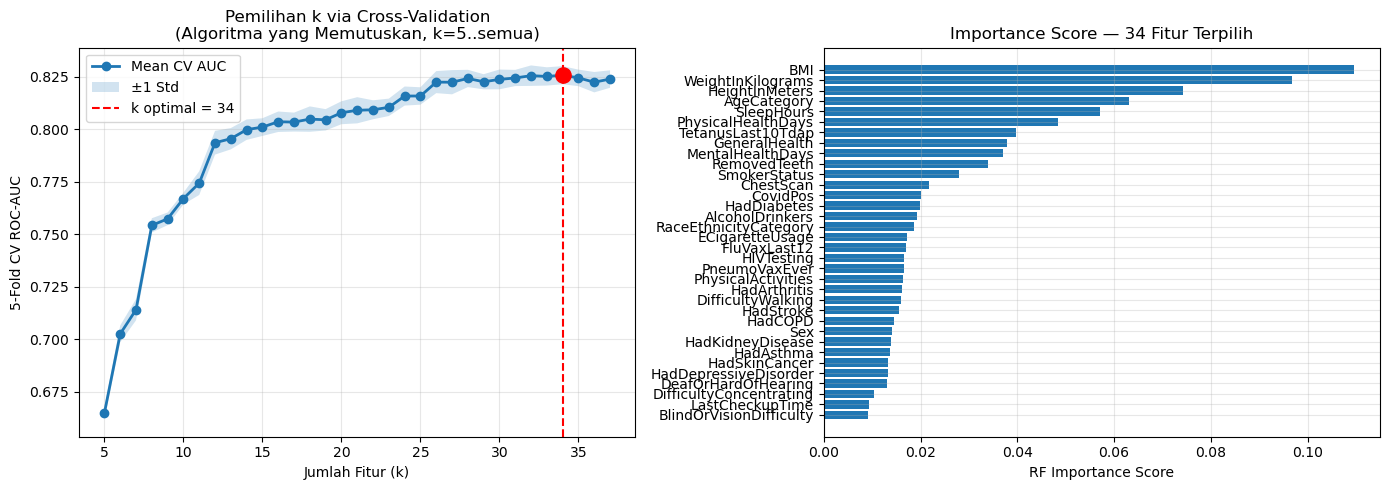

In [13]:
ks   = [r['k']        for r in results]
aucs = [r['mean_auc'] for r in results]
stds = [r['std_auc']  for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: ROC-AUC vs k (dengan error band)
aucs_arr = np.array(aucs)
stds_arr = np.array(stds)
axes[0].plot(ks, aucs, marker='o', linewidth=2, label='Mean CV AUC')
axes[0].fill_between(ks, aucs_arr - stds_arr, aucs_arr + stds_arr, alpha=0.2, label='±1 Std')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
axes[0].scatter([best_k], [best_auc], color='red', s=120, zorder=5)
axes[0].set_xlabel('Jumlah Fitur (k)')
axes[0].set_ylabel('5-Fold CV ROC-AUC')
axes[0].set_title('Pemilihan k via Cross-Validation\n(Algoritma yang Memutuskan, k=5..semua)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kanan: importance fitur terpilih
sel_imp = importances_sorted[selected_features]
axes[1].barh(sel_imp.index[::-1], sel_imp.values[::-1])
axes[1].set_xlabel('RF Importance Score')
axes[1].set_title(f'Importance Score — {best_k} Fitur Terpilih')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Persiapan Data Training

In [15]:
X_selected = X_full[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size  = 0.2,
    random_state = 42,
    stratify   = y       # jaga proporsi CHD di train & test
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Validasi: pastikan tidak ada NaN / Inf setelah scaling
assert not np.isnan(X_train_scaled).any(), 'NaN ditemukan di X_train_scaled!'
assert not np.isinf(X_train_scaled).any(), 'Inf ditemukan di X_train_scaled!'
print('✅ Tidak ada NaN/Inf setelah scaling')

# Reshape untuk CNN-LSTM: (samples, features, 1)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

print(f'X_train : {X_train_lstm.shape}')
print(f'X_test  : {X_test_lstm.shape}')
print(f'Fitur   : {best_k} (dipilih otomatis oleh algoritma)')
print(f'List    : {selected_features}')

✅ Tidak ada NaN/Inf setelah scaling
X_train : (196817, 34, 1)
X_test  : (49205, 34, 1)
Fitur   : 34 (dipilih otomatis oleh algoritma)
List    : ['BMI', 'WeightInKilograms', 'HeightInMeters', 'AgeCategory', 'SleepHours', 'PhysicalHealthDays', 'TetanusLast10Tdap', 'GeneralHealth', 'MentalHealthDays', 'RemovedTeeth', 'SmokerStatus', 'ChestScan', 'CovidPos', 'HadDiabetes', 'AlcoholDrinkers', 'RaceEthnicityCategory', 'ECigaretteUsage', 'FluVaxLast12', 'HIVTesting', 'PneumoVaxEver', 'PhysicalActivities', 'HadArthritis', 'DifficultyWalking', 'HadStroke', 'HadCOPD', 'Sex', 'HadKidneyDisease', 'HadAsthma', 'HadSkinCancer', 'HadDepressiveDisorder', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'LastCheckupTime', 'BlindOrVisionDifficulty']


## 8. Arsitektur CNN-LSTM

In [17]:
n_features = X_train_lstm.shape[1]

model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 33, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,243 (90.79 KB)

 Trainable params: 23,243 (90.79 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Training dengan Class Weighting & Early Stopping

In [19]:
classes = np.unique(y_train)
cw_arr  = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_arr))
print(f'Class weights: {cw_dict}')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train,
    epochs         = 100,
    batch_size     = 32,
    validation_split = 0.2,
    class_weight   = cw_dict,
    callbacks      = [early_stop],
    verbose        = 1
)

loss, acc = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

Class weights: {0: 0.5323550891239079, 1: 8.226759739174051}
Epoch 1/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.7044 - loss: 0.5731 - val_accuracy: 0.5433 - val_loss: 0.7831
Epoch 2/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 62s 13ms/step - accuracy: 0.7049 - loss: 0.5281 - val_accuracy: 0.7144 - val_loss: 0.4961
Epoch 3/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.7033 - loss: 0.5003 - val_accuracy: 0.6942 - val_loss: 0.5316
Epoch 4/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 67s 14ms/step - accuracy: 0.7077 - loss: 0.4922 - val_accuracy: 0.7176 - val_loss: 0.5168
Epoch 5/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.7168 - loss: 0.4885 - val_accuracy: 0.7552 - val_loss: 0.4492
Epoch 6/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 60s 12ms/step - accuracy: 0.7137 - loss: 0.4921 - val_accuracy: 0.7921 - val_loss: 0.3929
Epoch 7/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.7235 - loss: 0.4839 - val_accuracy: 0.7490 - val_loss: 0.4470
Epoch 8/

## 10. Evaluasi Model

1538/1538 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
Classification Report (Target: HadAngina / CHD):
              precision    recall  f1-score   support

     Non-CHD       0.98      0.80      0.88     46214
         CHD       0.19      0.72      0.30      2991

    accuracy                           0.79     49205
   macro avg       0.58      0.76      0.59     49205
weighted avg       0.93      0.79      0.84     49205

ROC-AUC Score : 0.8456


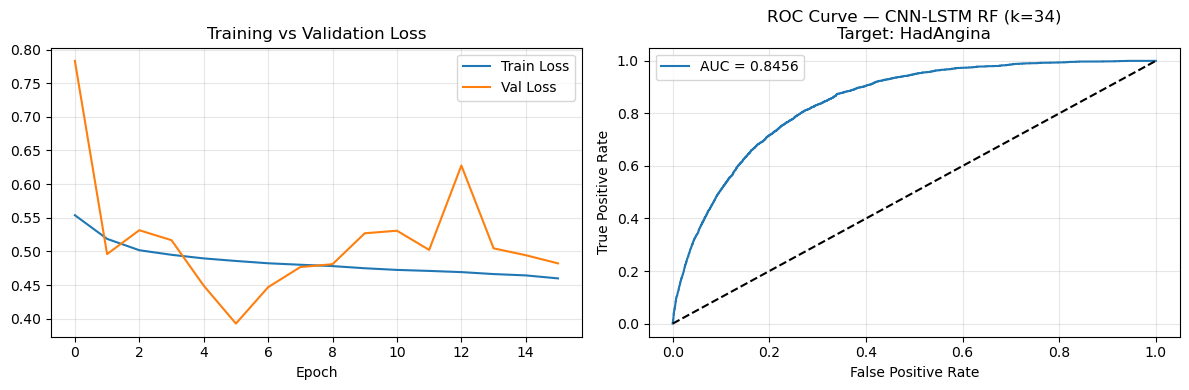

In [21]:
y_proba = model.predict(X_test_lstm).flatten()
y_pred  = (y_proba > 0.5).astype(int)

print('Classification Report (Target: HadAngina / CHD):')
print(classification_report(y_test, y_pred, target_names=['Non-CHD', 'CHD']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score : {roc_auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — CNN-LSTM RF (k={best_k})\nTarget: HadAngina')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Baseline Model — Perbandingan CNN-LSTM vs Random Forest Murni
Setelah CNN-LSTM selesai dilatih, kami membandingkan performanya dengan **Random Forest murni**  
pada fitur yang sama. Ini menjawab pertanyaan: *'Apakah CNN-LSTM memberikan nilai tambah dibanding model klasik?'*

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Baseline: Random Forest murni pada fitur yang sama dengan CNN-LSTM
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_rf_base  = rf_baseline.predict(X_test)
y_proba_rf_base = rf_baseline.predict_proba(X_test)[:, 1]
auc_rf_base     = roc_auc_score(y_test, y_proba_rf_base)

print('='*55)
print('BASELINE — Random Forest Murni (fitur yang sama)')
print('='*55)
print(classification_report(y_test, y_pred_rf_base, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC RF Baseline : {auc_rf_base:.4f}')
print()
print('='*55)
print('CNN-LSTM (model utama)')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC CNN-LSTM    : {roc_auc:.4f}')
print()
print('--- Perbandingan ---')
print(f'Delta ROC-AUC (CNN-LSTM - RF): {roc_auc - auc_rf_base:+.4f}')
if roc_auc > auc_rf_base:
    print('✅ CNN-LSTM lebih unggul dari RF biasa')
elif roc_auc == auc_rf_base:
    print('⚠️  CNN-LSTM setara dengan RF biasa')
else:
    print('⚠️  RF biasa lebih unggul — perlu justifikasi penggunaan CNN-LSTM')

BASELINE — Random Forest Murni (fitur yang sama)
              precision    recall  f1-score   support

     Non-CHD       0.94      1.00      0.97     46214
         CHD       0.53      0.01      0.03      2991

    accuracy                           0.94     49205
   macro avg       0.73      0.51      0.50     49205
weighted avg       0.91      0.94      0.91     49205

ROC-AUC RF Baseline : 0.8389

CNN-LSTM (model utama)
              precision    recall  f1-score   support

     Non-CHD       0.98      0.80      0.88     46214
         CHD       0.19      0.72      0.30      2991

    accuracy                           0.79     49205
   macro avg       0.58      0.76      0.59     49205
weighted avg       0.93      0.79      0.84     49205

ROC-AUC CNN-LSTM    : 0.8456

--- Perbandingan ---
Delta ROC-AUC (CNN-LSTM - RF): +0.0067
✅ CNN-LSTM lebih unggul dari RF biasa


## Threshold Tuning — Analisis Trade-off Presisi vs Recall
Threshold default 0.5 menghasilkan presisi CHD yang rendah (karena class imbalance).  
Di sini kita analisis trade-off: **naikkan threshold → presisi naik, recall turun**.  
Untuk skrining medis, **recall lebih penting** (hindari pasien CHD tidak terdeteksi).

 Threshold |  Precision |     Recall |         F1
------------------------------------------------
      0.20 |     0.1242 |     0.9181 |     0.2188
      0.25 |     0.1332 |     0.8910 |     0.2318
      0.30 |     0.1430 |     0.8653 |     0.2455
      0.35 |     0.1523 |     0.8332 |     0.2575
      0.40 |     0.1633 |     0.8021 |     0.2714
      0.45 |     0.1747 |     0.7623 |     0.2843
      0.50 |     0.1863 |     0.7212 |     0.2961
      0.55 |     0.2025 |     0.6737 |     0.3114
      0.60 |     0.2179 |     0.6152 |     0.3218
      0.65 |     0.2364 |     0.5463 |     0.3300
      0.70 |     0.2593 |     0.4721 |     0.3348

✅ Threshold optimal (F1 tertinggi): 0.70
   Precision = 0.2593
   Recall    = 0.4721
   F1-Score  = 0.3348


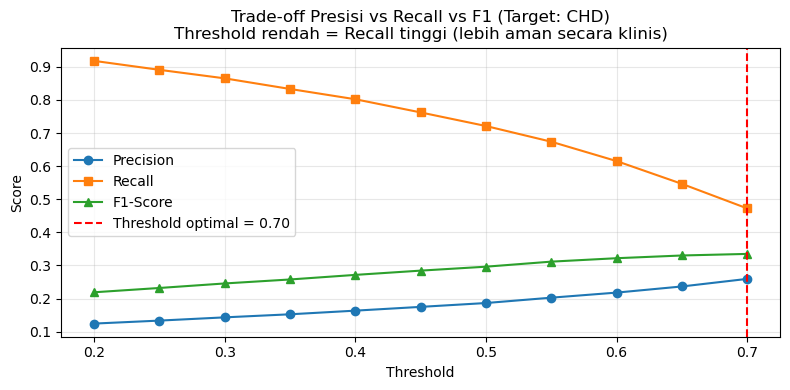

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds  = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
thr_results = []

print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>10} | {"F1":>10}')
print('-' * 48)

for thr in thresholds:
    y_t = (y_proba > thr).astype(int)
    # Hindari division by zero jika semua prediksi satu kelas
    try:
        prec = precision_score(y_test, y_t, zero_division=0)
        rec  = recall_score(y_test, y_t,    zero_division=0)
        f1   = f1_score(y_test, y_t,         zero_division=0)
    except:
        prec = rec = f1 = 0.0
    thr_results.append({'thr': thr, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f'{thr:>10.2f} | {prec:>10.4f} | {rec:>10.4f} | {f1:>10.4f}')

# Threshold dengan F1 tertinggi
best_thr = max(thr_results, key=lambda x: x['f1'])
print(f'\n✅ Threshold optimal (F1 tertinggi): {best_thr["thr"]:.2f}')
print(f'   Precision = {best_thr["precision"]:.4f}')
print(f'   Recall    = {best_thr["recall"]:.4f}')
print(f'   F1-Score  = {best_thr["f1"]:.4f}')

# Plot
plt.figure(figsize=(8, 4))
thrs  = [r['thr']       for r in thr_results]
precs = [r['precision'] for r in thr_results]
recs  = [r['recall']    for r in thr_results]
f1s   = [r['f1']        for r in thr_results]
plt.plot(thrs, precs, marker='o', label='Precision')
plt.plot(thrs, recs,  marker='s', label='Recall')
plt.plot(thrs, f1s,   marker='^', label='F1-Score')
plt.axvline(x=best_thr['thr'], color='red', linestyle='--',
            label=f'Threshold optimal = {best_thr["thr"]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Trade-off Presisi vs Recall vs F1 (Target: CHD)\n'
          'Threshold rendah = Recall tinggi (lebih aman secara klinis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Simpan Semua Artefak

In [27]:
# Model CNN-LSTM
model.save('model_rf_cnn_lstm.keras')
print(f'✅ model_rf_cnn_lstm.keras')

# Scaler (difit pada training data)
joblib.dump(scaler, 'scaler_rf.pkl')
print('✅ scaler_rf.pkl')

# Encoder (hanya kolom yang dipakai sebagai fitur)
encoders_used = {col: encoders[col] for col in selected_features if col in encoders}
joblib.dump(encoders_used, 'encoders_rf.pkl')
print('✅ encoders_rf.pkl  (hanya encoder fitur terpilih)')

# Metadata — backend WAJIB baca dari sini, jangan hardcode fitur di main.py
metadata_rf = {
    'target'            : TARGET,
    'dropped_cols'      : DROP_COLS,
    'selected_features' : selected_features,   # urutan penting untuk inferensi!
    'n_features'        : best_k,
    'k_search_range'    : [K_MIN, K_MAX],
    'method'            : 'RF Feature Importance + 5-Fold CV (k=5..semua fitur)',
    'best_cv_auc'       : round(best_auc, 4),
    'test_roc_auc'      : round(roc_auc, 4),
    'test_accuracy'     : round(float(acc), 4),
}
joblib.dump(metadata_rf, 'metadata_rf.pkl')
print('✅ metadata_rf.pkl')

print('\n========== RINGKASAN AKHIR ==========')
print(f'Target          : {TARGET}')
print(f'Rentang k dicek : {K_MIN} .. {K_MAX} (semua fitur tersedia)')
print(f'k optimal       : {best_k} (dipilih otomatis oleh algoritma)')
print(f'CV ROC-AUC      : {best_auc:.4f}')
print(f'Test ROC-AUC    : {roc_auc:.4f}')
print(f'Test Accuracy   : {acc:.4f}')
print(f'Fitur terpilih  : {selected_features}')
print('=====================================')

✅ model_rf_cnn_lstm.keras
✅ scaler_rf.pkl
✅ encoders_rf.pkl  (hanya encoder fitur terpilih)
✅ metadata_rf.pkl

========== RINGKASAN AKHIR ==========
Target          : HadAngina
Rentang k dicek : 5 .. 37 (semua fitur tersedia)
k optimal       : 34 (dipilih otomatis oleh algoritma)
CV ROC-AUC      : 0.8256
Test ROC-AUC    : 0.8456
Test Accuracy   : 0.7916
Fitur terpilih  : ['BMI', 'WeightInKilograms', 'HeightInMeters', 'AgeCategory', 'SleepHours', 'PhysicalHealthDays', 'TetanusLast10Tdap', 'GeneralHealth', 'MentalHealthDays', 'RemovedTeeth', 'SmokerStatus', 'ChestScan', 'CovidPos', 'HadDiabetes', 'AlcoholDrinkers', 'RaceEthnicityCategory', 'ECigaretteUsage', 'FluVaxLast12', 'HIVTesting', 'PneumoVaxEver', 'PhysicalActivities', 'HadArthritis', 'DifficultyWalking', 'HadStroke', 'HadCOPD', 'Sex', 'HadKidneyDisease', 'HadAsthma', 'HadSkinCancer', 'HadDepressiveDisorder', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'LastCheckupTime', 'BlindOrVisionDifficulty']
